## Initialization Libraries.

In [ ]:
# Import required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

## Step 1: Load the Dataset

In [ ]:
# Load dataset
df = pd.read_csv("spread_locator_dataset.csv")
df

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


In [ ]:
# Display first 5 rows
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [ ]:
# Display last 5 rows
df.tail()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success
219,c7d958bb-62b5-43a8-bfb9-30edc213fa85,CUST8260,3105.52,2023-01-28,1,South,Fail


In [ ]:
# Statistical Summary
df.describe()

,transaction_id,customer_id,transaction_amount,transaction_count,flag
count,0,0,220.000000,220.000000,220.0
mean,NaT,NaT,3365.192409,2.854545,1.0
min,NaT,NaT,804.420000,0.000000,1.0
25%,NaT,NaT,2124.205000,1.750000,1.0
50%,NaT,NaT,3077.715000,3.000000,1.0
75%,NaT,NaT,3950.737500,4.000000,1.0
max,NaT,NaT,20462.840000,9.000000,1.0
std,NaN,NaN,1985.705409,1.797189,0.0


In [ ]:
# Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB
None


## Task 1. Bernoulli & Binomial Distribution
Bernoulli distribution represents binary outcomes:
- Success = 1
- Failure = 0

Basically , we have to convert transaction_status into binary values.

In [ ]:
# Convert transaction status to binary
df["status_binary"] = df["transaction_status"].map({
    "Success": 1,
    "Fail": 0
})

# probability of success
p = df["status_binary"].mean()

print(f"Probability of Success: {p:.4f}")
print(f"Probability of Failure: {1 - p:.4f}")

Probability of Success: 0.4455
Probability of Failure: 0.5545


## Binomial Distribution
Binomial distribution represents number of successes in a fixed number of trials.

Formula:  Mean = n * p

In [30]:
# Binomial parameters
n = df["transaction_count"].max()
p = df["status_binary"].mean()

binomial_mean = n * p

print(f"Number of Trials (n): {n}")
print(f"Probability of Success (p): {p:.4f}")
print(f"Binomial Mean: {binomial_mean:.4f}")

Number of Trials (n): 9
Probability of Success (p): 0.4455
Binomial Mean: 4.0091


## Task 2: Poisson Distribution
Poisson distribution models the number of transactions per time period.


Poisson Lambda : 2.8545


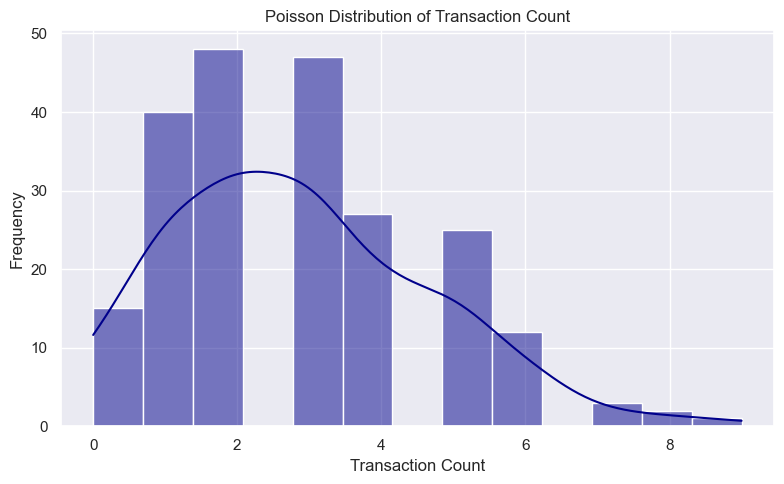

In [70]:
# Calculate lambda
lambda_val = df["transaction_count"].mean()
print(f"Poisson Lambda : {lambda_val:.4f}")

# Plot distribution
sns.set(style="darkgrid")
plt.figure(figsize=(8, 5))
sns.histplot(df["transaction_count"], kde=True, color="darkblue")
plt.title("Poisson Distribution of Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Task 3: Log-Normal Distribution
Transaction amounts typically follow a Log-Normal distribution because they are right-skewed and cannot be negative.

In [ ]:
# Log-Normal distribution
shape, loc, scale = stats.lognorm.fit(df["transaction_amount"], floc=0)

print(f"Shape Parameter : {shape:.4f}")
print(f"Scale Parameter : {scale:.4f}")

Shape Parameter : 0.4749
Scale Parameter : 2983.1591


## Power Law Distribution
Power Law distribution models heavy-tailed financial data.

In [39]:
# Power Law distribution
power = stats.powerlaw.fit(df["transaction_amount"])

print(f"Power Law Parameters: {power}")

Power Law Parameters: (np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


## Task 4: Q-Q Plot
A Q-Q plot compares the transaction amount distribution with the Normal distribution.

- If points lie on the straight line → data is normally distributed
- If points deviate → data is skewed

<Figure size 500x500 with 0 Axes>

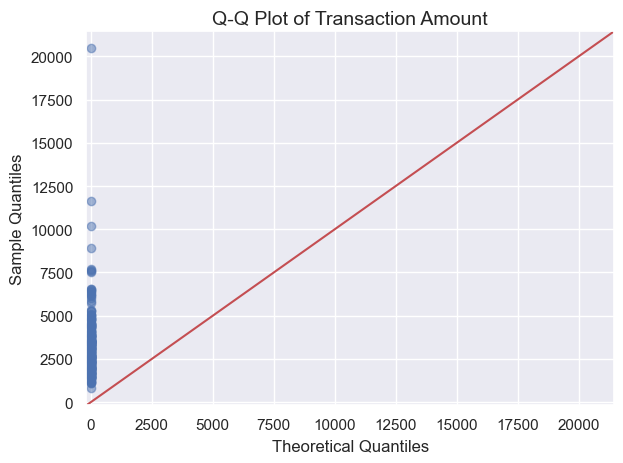

In [50]:
# Q-Q Plot
sns.set(style="darkgrid")
plt.figure(figsize=(5,5))
sm.qqplot(df["transaction_amount"], line='45', alpha=0.5)
plt.title("Q-Q Plot of Transaction Amount", fontsize=14)
plt.tight_layout()
plt.show()

## Task 5: Box-Cox Transformation
Box-Cox transformation helps normalize skewed data and stabilize variance.
- Note - It requires strictly positive values.

Optimal Lambda : -0.1812


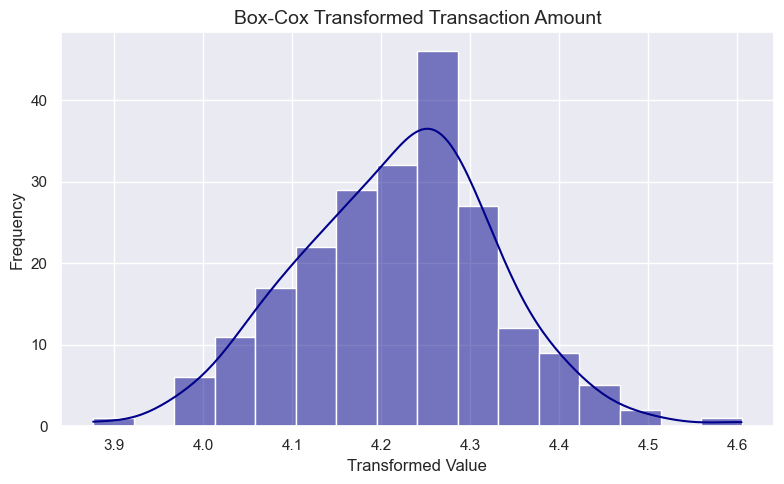

In [57]:
# Box-Cox transformation
data = df["transaction_amount"] + 1

boxcox_data, lam = stats.boxcox(data)

print(f"Optimal Lambda : {lam:.4f}")

# Plot transformed data
sns.set(style="darkgrid")
plt.figure(figsize=(8, 5))
sns.histplot(boxcox_data, kde=True, color="darkblue")
plt.title("Box-Cox Transformed Transaction Amount", fontsize=14)
plt.xlabel("Transformed Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Task 6: Z-Score Analysis
Z-score measures the distance from the mean in terms of standard deviations.
- Which is also used to detect outliers and extreme transactions.

In [63]:
# Z-score
df["z_score"] = stats.zscore(df["transaction_amount"])

print("Displaying First 5 rows:")
print(df[["transaction_amount", "z_score"]].head())

print("\nDisplaying Last 5 rows:")
print(df[["transaction_amount", "z_score"]].tail())

Displaying First 5 rows:
   transaction_amount   z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179

Displaying Last 5 rows:
     transaction_amount   z_score
215             4356.76  0.500492
216             2025.53 -0.676192
217             2648.08 -0.361961
218             2338.62 -0.518160
219             3105.52 -0.131069


In [64]:
# Probability of transaction exceeding ₹5000
probability = (df["transaction_amount"] > 5000).mean()

print(f"Probability (Transaction Amount > ₹5000): {probability:.4f}")

Probability (Transaction Amount > ₹5000): 0.1136


## Task 7: PDF and CDF
- PDF (Probability Density Function) → shows probability density at a specific value
- CDF (Cumulative Distribution Function) → shows cumulative probability up to a value


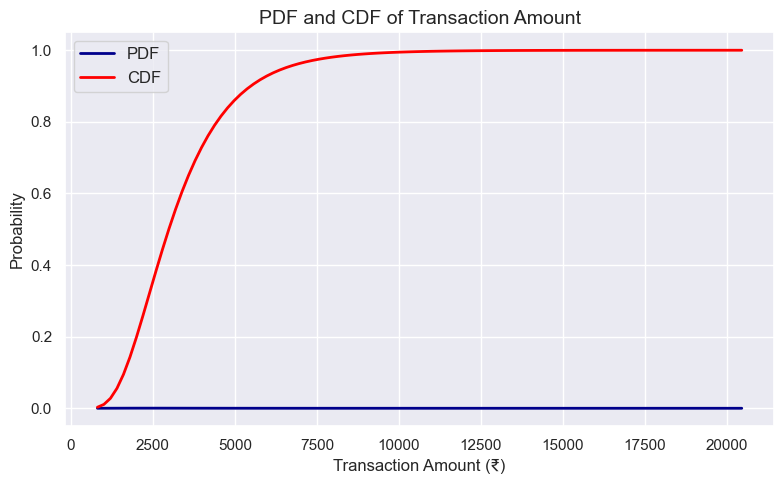

In [67]:
# Generate x values
x = np.linspace(
    df["transaction_amount"].min(),
    df["transaction_amount"].max(),
    100
)

# Calculate PDF and CDF using fitted Log-Normal parameters
pdf = stats.lognorm.pdf(x, shape, loc, scale)
cdf = stats.lognorm.cdf(x, shape, loc, scale)

# Plot Distribution
sns.set(style="darkgrid")
plt.figure(figsize=(8, 5))
plt.plot(x, pdf, label="PDF", color="darkblue", linewidth=2)
plt.plot(x, cdf, label="CDF", color="red", linewidth=2)
plt.legend(fontsize=12)
plt.title("PDF and CDF of Transaction Amount", fontsize=14)
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

## Conclusion
Based on the statistical analysis performed:

The dataset best fits a Log-Normal distribution because it is positively skewed with many small values and few large values. The Poisson distribution is suitable for modeling daily transaction counts. As it also helps in predicting transaction frequency for better decision-making.

This analysis helps businesses:

- Detect anomalies in transaction behavior
- Predict customer transaction patterns
- Improve financial modeling and risk assessment
